In [1]:
import zipfile

zip_path = "dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Done extracting ")

Done extracting 


In [2]:
!pip install transformers
!pip install opencv-python
!pip install pillow
!pip install scikit-learn

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
import os

from transformers import BertTokenizer
from transformers import TFBertModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import ResNet50

In [2]:
df = pd.read_csv(
    "dataset/dataset.csv"
)

print(df.head())

     image_path                   text  label class_name
0  images/0.jpg  tshirt fashion outfit      7     tshirt
1  images/1.jpg  tshirt fashion outfit      7     tshirt
2  images/2.jpg  tshirt fashion outfit      7     tshirt
3  images/3.jpg  tshirt fashion outfit      7     tshirt
4  images/4.jpg  tshirt fashion outfit      7     tshirt


# ENCODE LABELS

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

labels = label_encoder.fit_transform(df["class_name"])

# TOKENIZE TEXT

In [4]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
texts = df["text"].astype(str).tolist()

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

input_ids = pad_sequences(sequences, maxlen=50, padding="post", truncating="post")

SPLIT TRAIN/TEST

In [5]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

X_train_ids, X_test_ids, y_train, y_test = train_test_split(
    input_ids,
    labels,
    test_size=0.2,
    random_state=42
)

# BUILD GRU MODE

In [6]:
vocab_size = 30522  # BERT vocab size OR max token id
max_len = 50

In [7]:
from tensorflow.keras.layers import Input, Embedding, GRU, Dense
from tensorflow.keras.models import Model

input_layer = Input(shape=(50,), dtype=tf.int32)

x = Embedding(
    input_dim=vocab_size,
    output_dim=128,
    mask_zero=True
)(input_layer)

x = GRU(128)(x)

x = Dense(128, activation='relu')(x)

output = Dense(8, activation='softmax')(x)

gru_model = Model(inputs=input_layer, outputs=output)

# COMPILE GRU

In [8]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN GRU

In [9]:
gru_model.fit(
    X_train_ids,
    y_train,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.3716 - loss: 1.9526 - val_accuracy: 0.4458 - val_loss: 1.5838
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9063 - loss: 0.6167 - val_accuracy: 1.0000 - val_loss: 0.0673
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 7.0495e-04
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 1.0000 - loss: 4.5261e-04 - val_accuracy: 1.0000 - val_loss: 4.6026e-04
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 1.0000 - loss: 3.3340e-04 - val_accuracy: 1.0000 - val_loss: 3.4821e-04
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 1.0000 - loss: 2.6204e-04 - val_accuracy: 1.0000 - val_loss: 2.7710e-04
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 1.0000 - loss: 2.1171e-04 - val_accuracy: 1.0000 - val_loss: 2.2584e-04
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 1.0000 - 

# TEST GRU

In [10]:
loss, accuracy = gru_model.evaluate(X_test_ids, y_test)

print("GRU Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 1.3316e-04
GRU Accuracy: 1.0


# SAVE GRU

In [11]:
import os

os.makedirs("saved_models", exist_ok=True)

In [12]:
gru_model.save("saved_models/gru_model.keras")

# ResNet50

# LOAD IMAGES

In [13]:
import cv2

images = []

labels_img = []

for index, row in df.iterrows():

    path = "dataset/" + row["image_path"]

    img = cv2.imread(path)

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    images.append(img)

    labels_img.append(row["label"])

X_images = np.array(images)

y = np.array(labels_img)

# SPLIT TRAIN/TEST

In [14]:
X_train_img, X_test_img, \
y_train_img, y_test_img = train_test_split(

    X_images,
    y,

    test_size=0.2,
    random_state=42
)

# BUILD RESNET50

In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

outputs = Dense(
    8,
    activation='softmax'
)(x)

resnet_model = Model(
    inputs,
    outputs
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# COMPILE RESNET50

In [16]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN RESNET50

In [17]:
resnet_model.fit(

    X_train_img,
    y_train_img,

    epochs=10,

    batch_size=32,

    validation_split=0.2
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 92s 8s/step - accuracy: 0.1571 - loss: 2.1350 - val_accuracy: 0.1928 - val_loss: 2.0930
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.1692 - loss: 2.0545 - val_accuracy: 0.1566 - val_loss: 2.0817
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 100s 9s/step - accuracy: 0.2054 - loss: 2.0272 - val_accuracy: 0.1807 - val_loss: 2.0395
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.2628 - loss: 1.9497 - val_accuracy: 0.1687 - val_loss: 1.9972
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 74s 7s/step - accuracy: 0.2779 - loss: 1.9396 - val_accuracy: 0.2410 - val_loss: 1.9740
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 88s 7s/step - accuracy: 0.2447 - loss: 1.9471 - val_accuracy: 0.2048 - val_loss: 2.0490
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.2749 - loss: 1.8859 - val_accuracy: 0.2410 - val_loss: 1.9264
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - accuracy: 0.2840 - loss: 1.8947 - val_accuracy: 0.2169 - val_loss

# TEST RESNET50

In [18]:
loss, accuracy = resnet_model.evaluate(

    X_test_img,
    y_test_img
)

print(
    "ResNet50 Accuracy:",
    accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.2788 - loss: 1.9087
ResNet50 Accuracy: 0.2788461446762085


# SAVE RESNET50

In [19]:
resnet_model.save(
    "saved_models/resnet50_model.keras"
)

# REMOVE FINAL LAYER

# GRU FEATURE EXTRACTOR

In [20]:
gru_feature_model = Model(

    inputs=gru_model.input,

    outputs=gru_model.layers[-2].output
)

# RESNET50 FEATURE EXTRACTOR

In [21]:
resnet_feature_model = Model(

    inputs=resnet_model.input,

    outputs=resnet_model.layers[-2].output
)

# EXTRACT TEXT FEATURES

In [25]:
text_features = gru_feature_model.predict(
    X_padded
)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


# EXTRACT IMAGE FEATURES

In [26]:
image_features = resnet_feature_model.predict(
    X_images
)

print(text_features.shape)
print(image_features.shape)


17/17 ━━━━━━━━━━━━━━━━━━━━ 107s 6s/step
(518, 128)
(518, 128)


# COMBINE FEAUTRES

In [27]:
combined_features = np.concatenate(

    [text_features, image_features],

    axis=1
)

print(combined_features.shape)

(518, 256)


# BUILD FINAL MULTIMODAL MODEL

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

multimodal_model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(
            combined_features.shape[1],
        )
    ),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        8,
        activation='softmax'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILE MODEL

In [29]:
multimodal_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# TRAIN FINAL MODEL

In [30]:
multimodal_model.fit(

    combined_features,

    y,

    epochs=10,

    batch_size=32
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9131 - loss: 0.4884
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 5.5910e-04
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.1667e-04
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.4413e-04
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.0364e-04
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.7406e-04
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.5063e-04
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.3139e-04
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.1502e-04


# TEST MODEL

In [31]:
predictions = multimodal_model.predict(
    combined_features
)

print(predictions[:5])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[1.93871060e-07 2.82399178e-05 2.16342050e-06 3.01634700e-05
  2.89616255e-05 4.27543625e-07 9.72933112e-09 9.99909699e-01]
 [2.09888299e-07 3.78846016e-05 2.88353931e-06 2.59439130e-05
  2.64435021e-05 4.26263739e-07 1.02872653e-08 9.99906123e-01]
 [1.85814656e-07 3.28451424e-05 2.60743036e-06 2.86740378e-05
  2.67433315e-05 4.36947943e-07 1.01062625e-08 9.99908388e-01]
 [2.08572160e-07 3.11579097e-05 2.40826057e-06 3.07709561e-05
  2.69630746e-05 4.78191055e-07 9.56534851e-09 9.99908030e-01]
 [1.41975761e-07 2.18773748e-05 1.87218734e-06 2.96048274e-05
  2.52202608e-05 3.10573853e-07 6.43367404e-09 9.99920905e-01]]


# SAVE FINAL MODEL

In [32]:
multimodal_model.save(
    "saved_models/multimodal_model.keras"
)

# LOAD FINAL MODELS

In [33]:
from tensorflow.keras.models import load_model

gru_model = load_model(
    "saved_models/gru_model.keras"
)

resnet_model = load_model(
    "saved_models/resnet50_model.keras"
)

# CREATE FEATURE EXTRACTORS

In [34]:
# GRU Feature Extractor
gru_feature_extractor = Model(

    inputs=gru_model.input,

    outputs=gru_model.layers[-2].output
)

# ResNet50 Feature Extractor
resnet_feature_extractor = Model(

    inputs=resnet_model.input,

    outputs=resnet_model.layers[-2].output
)

# EXTRACT TEXT FEATURES

In [35]:
text_features = gru_feature_extractor.predict(
    X_padded
)

print(text_features.shape)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
(518, 128)


# EXTRACT IMAGE FEAUTERS

In [36]:
image_features = resnet_feature_extractor.predict(
    X_images
)

print(image_features.shape)

17/17 ━━━━━━━━━━━━━━━━━━━━ 103s 6s/step
(518, 128)


# COMBINE FEATURES

In [37]:
combined_features = np.concatenate(

    [text_features, image_features],

    axis=1
)

print(combined_features.shape)

(518, 256)


# SAVE FEATURES

In [38]:
np.save(
    "combined_features.npy",
    combined_features
)

np.save(
    "labels.npy",
    y
)

In [39]:
pip install scikit-learn

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

# UPLOAD IMAGE

Saving 11.jpg to 11 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


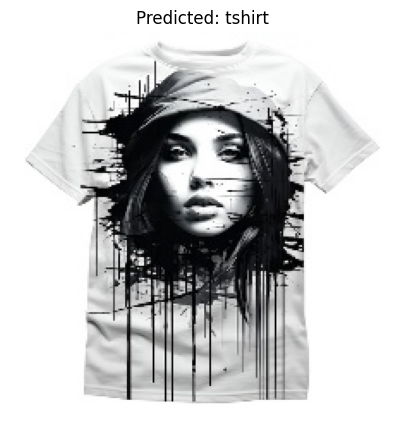

In [47]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
query_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(query_path)

# Convert BGR → RGB
img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# Resize for model
img_resized = cv2.resize(
    img,
    (224,224)
)

img_resized = img_resized / 255.0

query_image = np.expand_dims(
    img_resized,
    axis=0
)

# Predict
prediction = resnet_model.predict(
    query_image
)

predicted_index = np.argmax(
    prediction
)

predicted_class = label_encoder.inverse_transform(
    [predicted_index]
)[0]

# Show image + predicted label
plt.figure(figsize=(5,5))

plt.imshow(img_rgb)

plt.title(
    f"Predicted: {predicted_class}"
)

plt.axis("off")

plt.show()

Saving 183.jpg to 183.jpg


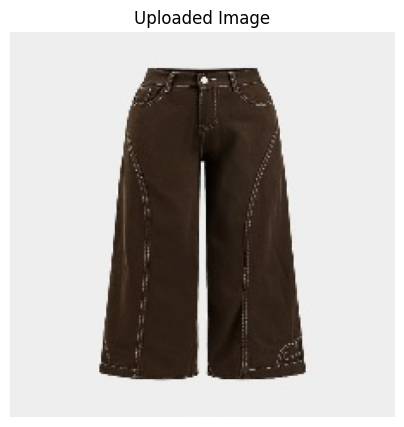

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Predicted Class: jeans


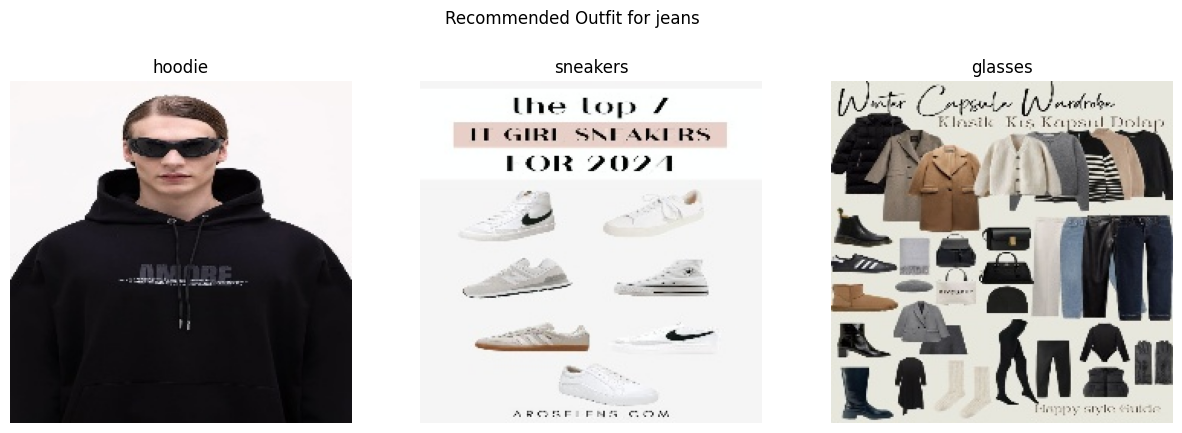

In [61]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random

# =========================================
# UPLOAD IMAGE
# =========================================

uploaded = files.upload()

query_path = list(uploaded.keys())[0]

# =========================================
# READ IMAGE
# =========================================

img = cv2.imread(query_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# =========================================
# SHOW INPUT IMAGE
# =========================================

plt.figure(figsize=(5,5))

plt.imshow(img_rgb)

plt.title("Uploaded Image")

plt.axis("off")

plt.show()

# =========================================
# PREPROCESS IMAGE
# =========================================

img_resized = cv2.resize(
    img,
    (224,224)
)

img_resized = img_resized / 255.0

query_image = np.expand_dims(
    img_resized,
    axis=0
)

# =========================================
# PREDICT CLASS
# =========================================

prediction = resnet_model.predict(
    query_image
)

predicted_index = np.argmax(
    prediction
)

predicted_class = label_encoder.inverse_transform(
    [predicted_index]
)[0]

print("Predicted Class:", predicted_class)

# =========================================
# SMART OUTFIT RULES
# =========================================

OUTFIT_MAP = {

    "hoodie": [
        "jeans",
        "sneakers",
        "glasses"
    ],

    "tshirt": [
        "jeans",
        "sneakers",
        "glasses"
    ],

    "jacket": [
        "jeans",
        "sneakers",
        "glasses"
    ],

    "dress": [
        "glasses",
        "sneakers"
    ],

    "shorts": [
        "tshirt",
        "sneakers",
        "glasses"
    ],

    "jeans": [
        "hoodie",
        "sneakers",
        "glasses"
    ],

    "sneakers": [
        "hoodie",
        "jeans",
        "glasses"
    ],

    "glasses": [
        "hoodie",
        "jeans",
        "sneakers"
    ]
}

# =========================================
# GET RECOMMENDED CATEGORIES
# =========================================

recommended_categories = OUTFIT_MAP.get(
    predicted_class,
    []
)

# =========================================
# SHOW RECOMMENDED OUTFIT
# =========================================

plt.figure(figsize=(15,5))

plot_index = 1

used_bottom = False

for category in recommended_categories:

    matching_items = df[
        df["class_name"] == category
    ]

    # لو مفيش صور للكلاس
    if len(matching_items) == 0:
        continue

    # منع jeans + shorts مع بعض
    if category in ["jeans", "shorts"]:

        if used_bottom:
            continue

        used_bottom = True

    random_item = matching_items.sample(1)

    img_path = os.path.join(
        "dataset",
        random_item.iloc[0]["image_path"]
    )

    rec_img = cv2.imread(img_path)

    rec_img = cv2.cvtColor(
        rec_img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(
        1,
        len(recommended_categories),
        plot_index
    )

    plt.imshow(rec_img)

    plt.title(category)

    plt.axis("off")

    plot_index += 1

plt.suptitle(
    f"Recommended Outfit for {predicted_class}"
)

plt.show()